Detected data types: KE, PE, DKE
Number of time steps: 202


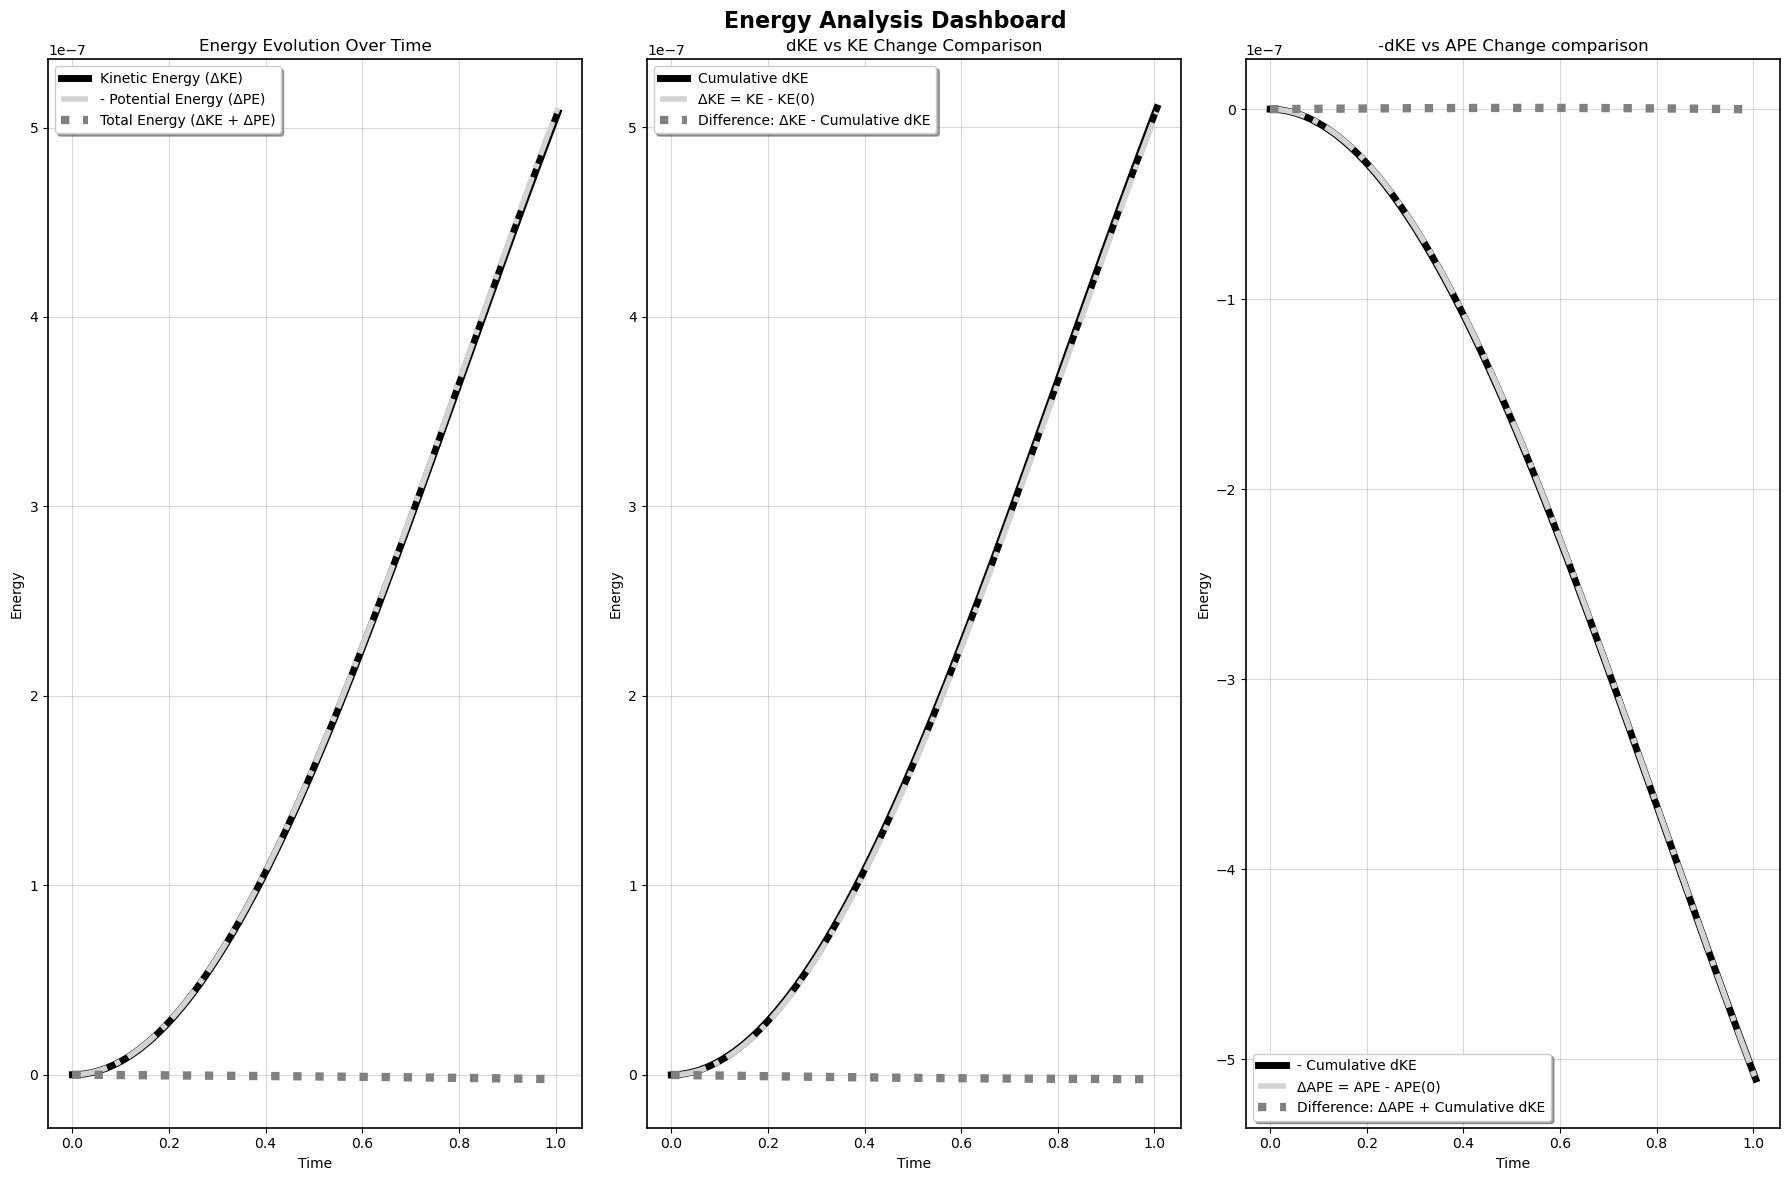


ENERGY ANALYSIS SUMMARY
Initial KE: 0.000000e+00
Final KE: 5.080449e-07
KE Change: 5.080449e-07
Cumulative dKE: 5.102792e-07
Residual (ΔKE - Cum.dKE): -2.234252e-09
Initial APE: 0.000000e+00
Final APE: -5.103792e-07
APE Change: -5.103792e-07
Total Energy Change: -2.334288e-09
DETAILED ENERGY EVOLUTION TABLE
Total time steps: 202


,Time,KE,APE,Cumul. dKE,Total Energy,ΔKE,Residual
0,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.0050,1.763707e-11,-1.763707e-11,3.527382e-11,-1.650173e-20,1.763707e-11,-1.763675e-11
2,0.0100,7.054606e-11,-7.867953e-11,1.058178e-10,-8.133464e-12,7.054606e-11,-3.527178e-11
3,0.0150,1.587215e-10,-1.749890e-10,2.116251e-10,-1.626746e-11,1.587215e-10,-5.290355e-11
4,0.0200,2.821544e-10,-3.065569e-10,3.526850e-10,-2.440247e-11,2.821544e-10,-7.053063e-11
5,0.0250,4.408321e-10,-4.733711e-10,5.289837e-10,-3.253898e-11,4.408321e-10,-8.815158e-11
6,0.0300,6.347385e-10,-6.754160e-10,7.405035e-10,-4.067749e-11,6.347385e-10,-1.057650e-10
7,0.0350,8.638540e-10,-9.126725e-10,9.872234e-10,-4.881848e-11,8.638540e-10,-1.233694e-10
8,0.0400,1.128155e-09,-1.185118e-09,1.269119e-09,-5.696243e-11,1.128155e-09,-1.409633e-10
9,0.0450,1.427616e-09,-1.492726e-09,1.586162e-09,-6.510985e-11,1.427616e-09,-1.585455e-10


In [1]:
# read especData.dat in the output
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# Set matplotlib to use grayscale
plt.rcParams['axes.prop_cycle'] = plt.cycler('color', ['black', 'gray', 'dimgray', 'lightgray', 'darkgray'])

# Load the data from the file
with open('../../output/especData.dat', 'r') as f:
    lines = f.readlines()

# Process the data
i = 0
times = []
ke_data = []
pe_data = []
dke_data = []
has_pe2 = False
while i < len(lines):

    current_set = {}
    set_start = i
    
    while i < len(lines):
        line = lines[i].strip()
        if line:
            parts = line.split()
            label = parts[0].rstrip(':').upper()
            time_val = float(parts[1])
            data_vals = [float(x) for x in parts[2:]]
            
            current_set[label] = {'time': time_val, 'data': data_vals}
            i += 1
            
            # Check if we have a complete set (at minimum KE, PE, DKE)
            if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
                # Check if there's a PE2 in the next line
                if i < len(lines):
                    next_line = lines[i].strip()
                    if next_line and next_line.split()[0].rstrip(':').upper() == 'PE2':
                        continue  # Read PE2 as well
                break
        else:
            i += 1
    
    # Store the data from current set
    if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
        times.append(current_set['KE']['time'])
        ke_data.append(current_set['KE']['data'])
        pe_data.append(current_set['PE']['data'])
        dke_data.append(current_set['DKE']['data'])

ke_data = np.array(ke_data)
pe_data = np.array(pe_data)
dke_data = np.array(dke_data)
times = np.array(times)

# Calculate total energy
total_ke = np.sum(ke_data, axis=1) # TODO: remove 0.5 for future run
total_pe = np.sum(pe_data, axis=1)
total_ke = total_ke - total_ke[0]  # Normalize kinetic energy
total_pe = total_pe - total_pe[0]  # Normalize potential energy

total_energy = total_ke + total_pe

# Calculate time step sizes and integrate dKE properly
time_steps = np.diff(times)
time_steps = np.append(time_steps[0], time_steps)  # Use first time step for initial value
total_dke_per_step = np.sum(dke_data, axis=1) * time_steps
total_dke = np.cumsum(total_dke_per_step)

# Print information about detected data
print(f"Detected data types: KE, PE, DKE", end="")
print()
print(f"Number of time steps: {len(times)}")

# Define consistent line styles for each type of data
line_styles = {
    'actual': {'linestyle': '-', 'linewidth': 5.0, 'color': 'black'},           # Solid black - main data
    'reference': {'linestyle': '-.', 'linewidth': 4.0, 'color': 'lightgray'},     # Dashed dark gray - reference/comparison
    'difference': {'linestyle': ':', 'linewidth': 6.0, 'color': 'gray'},        # Dotted gray - differences/residuals
    'negative': {'linestyle': '-.', 'linewidth': 4.0, 'color': 'lightgray'}      # Dash-dot dark gray - negative values
}

fig, axes = plt.subplots(1, 3, figsize=(18, 12))
fig.suptitle('Energy Analysis Dashboard', fontsize=16, fontweight='bold', color='black')

# 1. Energy Evolution Over Time
ax1 = axes[0]
ax1.plot(times, total_ke, label='Kinetic Energy (ΔKE)', **line_styles['actual'])
ax1.plot(times, -total_pe, label='- Potential Energy (ΔPE)', **line_styles['negative'])
ax1.plot(times, total_energy, label='Total Energy (ΔKE + ΔPE)', **line_styles['difference'])
ax1.set_xlabel('Time', color='black')
ax1.set_ylabel('Energy', color='black')
ax1.set_title('Energy Evolution Over Time', color='black')
ax1.legend(frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, color='gray')
ax1.tick_params(colors='black')

# 2. dKE Analysis for KE
ax2 = axes[1]
ax2.plot(times, total_dke, label='Cumulative dKE', **line_styles['actual'])
ax2.plot(times, total_ke-total_ke[0], label='ΔKE = KE - KE(0)', **line_styles['reference'])
difference_ke = (total_ke - total_ke[0]) - total_dke
ax2.plot(times, difference_ke, label='Difference: ΔKE - Cumulative dKE', **line_styles['difference'])
ax2.set_xlabel('Time', color='black')
ax2.set_ylabel('Energy', color='black')
ax2.set_title('dKE vs KE Change Comparison', color='black')
ax2.legend(frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, color='gray')
ax2.tick_params(colors='black')

# 3. dKE Analysis for PE
ax3 = axes[2]
ax3.plot(times, -total_dke, label='- Cumulative dKE', **line_styles['actual'])
ax3.plot(times, total_pe, label='ΔAPE = APE - APE(0)', **line_styles['negative'])
difference_pe = (total_pe - total_pe[0]) - (-total_dke)
ax3.plot(times, difference_pe, label='Difference: ΔAPE + Cumulative dKE', **line_styles['difference'])
ax3.set_xlabel('Time', color='black')
ax3.set_ylabel('Energy', color='black')
ax3.set_title('-dKE vs APE Change comparison', color='black')
ax3.legend(frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.3, color='gray')
ax3.tick_params(colors='black')

# Set all axes to have black spines
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

# Time stamp table with grayscale styling
detailed_data = []
for i, t in enumerate(times):
    row = {
        'Time': f'{t:.4f}',
        'KE': f'{total_ke[i]:.6e}',
        'APE': f'{total_pe[i]:.6e}',
        'Cumul. dKE': f'{total_dke[i]:.6e}',
        'Total Energy': f'{total_energy[i]:.6e}',
        'ΔKE': f'{total_ke[i] - total_ke[0]:.6e}',
        'Residual': f'{(total_ke[i] - total_ke[0]) - total_dke[i]:.6e}'
    }
    detailed_data.append(row)

df = pd.DataFrame(detailed_data)

styled_df = df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#40466e'), ('color', 'white'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
    {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
])

print("\n" + "="*60)
print("ENERGY ANALYSIS SUMMARY")
print("="*60)
print(f"Initial KE: {total_ke[0]:.6e}")
print(f"Final KE: {total_ke[-1]:.6e}")
print(f"KE Change: {total_ke[-1] - total_ke[0]:.6e}")
print(f"Cumulative dKE: {total_dke[-1]:.6e}")
print(f"Residual (ΔKE - Cum.dKE): {difference_ke[-1]:.6e}")
print(f"Initial APE: {total_pe[0]:.6e}")
print(f"Final APE: {total_pe[-1]:.6e}")
print(f"APE Change: {total_pe[-1] - total_pe[0]:.6e}")
print(f"Total Energy Change: {total_energy[-1] - total_energy[0]:.6e}")
print("="*60)
print("DETAILED ENERGY EVOLUTION TABLE")
print("="*60)
print(f"Total time steps: {len(times)}")
display(styled_df)

PE2 contains the linear term

In [2]:
# # read especData.dat in the output
# import numpy as np
# import pandas as pd
# from IPython.display import display, HTML
# import matplotlib.pyplot as plt

# # Load the data from the file
# with open('../../output/especData.dat', 'r') as f:
#     lines = f.readlines()

# # Process the data
# i = 0
# times = []
# ke_data = []
# pe_data = []
# pe2_data = []
# dke_data = []
# has_pe2 = False
# while i < len(lines):

#     current_set = {}
#     set_start = i
    
#     while i < len(lines):
#         line = lines[i].strip()
#         if line:
#             parts = line.split()
#             label = parts[0].rstrip(':').upper()
#             time_val = float(parts[1])
#             data_vals = [float(x) for x in parts[2:]]
            
#             current_set[label] = {'time': time_val, 'data': data_vals}
#             i += 1
            
#             # Check if we have a complete set (at minimum KE, PE, DKE)
#             if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
#                 # Check if there's a PE2 in the next line
#                 if i < len(lines):
#                     next_line = lines[i].strip()
#                     if next_line and next_line.split()[0].rstrip(':').upper() == 'PE2':
#                         continue  # Read PE2 as well
#                 break
#         else:
#             i += 1
    
#     # Store the data from current set
#     if 'KE' in current_set and 'PE' in current_set and 'DKE' in current_set:
#         times.append(current_set['KE']['time'])
#         ke_data.append(current_set['KE']['data'])
#         pe_data.append(current_set['PE']['data'])
#         dke_data.append(current_set['DKE']['data'])
        
#         # Check for PE2
#         if 'PE2' in current_set:
#             pe2_data.append(current_set['PE2']['data'])
#             has_pe2 = True
#         elif has_pe2:  # If we had PE2 before but not now, pad with zeros
#             pe2_data.append([0.0] * len(current_set['PE']['data']))

# ke_data = np.array(ke_data)
# pe_data = np.array(pe_data)
# dke_data = np.array(dke_data)
# times = np.array(times)

# if has_pe2:
#     pe2_data = np.array(pe2_data)

# # Calculate total energy
# total_ke = np.sum(ke_data, axis=1)*0.5
# total_pe = np.sum(pe_data, axis=1)
# total_pe = total_pe - total_pe[0]  # Normalize potential energy

# total_energy = total_ke + total_pe

# # Calculate time step sizes and integrate dKE properly
# time_steps = np.diff(times)
# time_steps = np.append(time_steps[0], time_steps)  # Use first time step for initial value
# total_dke_per_step = np.sum(dke_data, axis=1) * time_steps
# total_dke = np.cumsum(total_dke_per_step)
# if has_pe2:
#     total_pe2_per_step = np.sum(pe2_data, axis=1) * time_steps
#     total_pe2 = np.cumsum(total_pe2_per_step)
#     total_dpe = -total_dke+total_pe2

# # Print information about detected data
# print(f"Detected data types: KE, PE, DKE", end="")
# if has_pe2:
#     print(", PE2")
# else:
#     print()
# print(f"Number of time steps: {len(times)}")

# fig, axes = plt.subplots(1, 3, figsize=(18, 12))
# fig.suptitle('Energy Analysis Dashboard', fontsize=16, fontweight='bold')

# # 1. Energy Evolution Over Time
# # ax1 = axes[0]
# # ax1.plot(times, total_ke, label='Kinetic Energy (KE)', linestyle='-', linewidth=2, color='blue')
# # # ax1.plot(times, total_pe, label='Potential Energy (PE)', linestyle='-', linewidth=2, color='red')
# # ax1.plot(times, total_energy, label='Total Energy (KE + PE)', linestyle='--', linewidth=2, color='black')
# # ax1.set_xlabel('Time')
# # ax1.set_ylabel('Energy')
# # ax1.set_title('Energy Evolution Over Time')
# # ax1.legend()
# # ax1.grid(True, alpha=0.3)

# # 1. dPE Analysis
# ax1 = axes[0]
# ax1.plot(times, total_dpe, label='Cumulative dPE', linestyle='-', linewidth=2, color='green')
# ax1.plot(times, total_pe-total_pe[0], label='ΔPE = PE - PE(0)', linestyle='--', linewidth=2, color='blue')
# difference = (total_pe - total_pe[0]) - total_dpe
# ax1.plot(times, difference, label='Difference: ΔPE - Cumulative dPE', linestyle=':', linewidth=2, color='red')
# ax1.set_xlabel('Time')
# ax1.set_ylabel('Energy')
# ax1.set_title('dPE vs PE Change')
# ax1.legend()
# ax1.grid(True, alpha=0.3)

# # 2. dKE Analysis
# ax2 = axes[1]
# ax2.plot(times, total_dke, label='Cumulative dKE', linestyle='-', linewidth=2, color='green')
# ax2.plot(times, total_ke-total_ke[0], label='ΔKE = KE - KE(0)', linestyle='--', linewidth=2, color='blue')
# difference = (total_ke - total_ke[0]) - total_dke
# ax2.plot(times, difference, label='Difference: ΔKE - Cumulative dKE', linestyle=':', linewidth=2, color='red')
# ax2.set_xlabel('Time')
# ax2.set_ylabel('Energy')
# ax2.set_title('dKE vs KE Change')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# # 3. Total energy
# ax3 = axes[2]
# ax3.plot(times, total_dpe+total_dke, label='Net Energy Change', linestyle='-', linewidth=2, color='green')
# ax3.plot(times,total_pe-total_pe[0]+total_ke-total_ke[0], label='Total Energy Change', linestyle='--', linewidth=2, color='blue')
# ax3.set_xlabel('Time')
# ax3.set_ylabel('Energy Difference')
# ax3.set_title('d(KE+PE) vs (PE+KE) Change')
# ax3.grid(True, alpha=0.3)
# ax3.legend()
# ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# plt.tight_layout()
# plt.show()

# # Time stamp table
# detailed_data = []
# for i, t in enumerate(times):
#     row = {
#         'Time': f'{t:.4f}',
#         'KE': f'{total_ke[i]:.6e}',
#         'ΔKE': f'{total_ke[i] - total_ke[0]:.6e}',
#         'Cumul. dKE': f'{total_dke[i]:.6e}',
#         'KE Residual': f'{(total_ke[i] - total_ke[0]) - total_dke[i]:.6e}',
#         'PE': f'{total_pe[i]:.6e}',
#         'ΔPE': f'{total_pe[i] - total_pe[0]:.6e}',
#         'Cumul. dPE': f'{total_dpe[i]:.6e}',
#         'PE Residual': f'{(total_pe[i] - total_pe[0]) - total_dpe[i]:.6e}',
#         'Total Energy Change': f'{(total_energy[i] - total_energy[0]):.6e}',
#     }
#     if has_pe2:
#         row['Net cum dPE+dKE'] = f'{(total_pe2[i] - total_pe2[0]):.6e}'
#     detailed_data.append(row)

# df = pd.DataFrame(detailed_data)

# styled_df = df.style.set_properties(**{
#     'text-align': 'center',
#     'font-size': '10px'
# }).set_table_styles([
#     {'selector': 'th', 'props': [('background-color', '#40466e'), ('color', 'white'), ('font-weight', 'bold')]},
#     {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
#     {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%')]}
# ])

# print("\n" + "="*60)
# print("ENERGY ANALYSIS SUMMARY")
# print("="*60)
# print(f"Initial KE: {total_ke[0]:.6e}")
# print(f"Final KE: {total_ke[-1]:.6e}")
# print(f"KE Change: {total_ke[-1] - total_ke[0]:.6e}")
# print(f"Cumulative dKE: {total_dke[-1]:.6e}")
# print(f"Residual (ΔKE - Cum.dKE): {difference[-1]:.6e}")
# print(f"Initial PE: {total_pe[0]:.6e}")
# print(f"Final PE: {total_pe[-1]:.6e}")
# print(f"PE Change: {total_pe[-1] - total_pe[0]:.6e}")
# print(f"Cumulative dPE: {total_dpe[-1]:.6e}")
# print(f"Residual (ΔPE - Cum.dPE): {difference[-1]:.6e}")
# print(f"Total Energy Change: {total_energy[-1] - total_energy[0]:.6e}")
# print(f"Cumulative d(KE+PE): {total_dke[-1] + total_dpe[-1]:.6e}")
# if has_pe2:
#     print(f"PE2 Change: {total_pe2[-1] - total_pe2[0]:.6e}")
# print("="*60)
# print("DETAILED ENERGY EVOLUTION TABLE")
# print("="*60)
# print(f"Total time steps: {len(times)}")
# display(styled_df)